## Q-Learning

Le Q-Learning est à RL ce que la Régression Linéaire est au ML supervisé — c'est le premier algorithme qu'on apprend, pas parce qu'il est le meilleur, mais parce qu'il est le plus pédagogique.


### Définition

Le Q-Learning est un algorithme de Reinforcement Learning de type **Value-Based**. Il permet à un agent d'apprendre la **meilleure action à faire dans chaque situation,** en construisant progressivement une table de valeurs appelée **Q-Table**

> Le Q signifie Quality — la qualité d'une action a dans un état s.

**L'idée fondamentale:**

L'agent ne sait pas au départ quoi faire. Il va explorer l'environnement, recevoir des récompenses, et progressivement apprendre quelles actions sont bonnes ou mauvaises.

Au début         →  l'agent fait n'importe quoi (exploration aléatoire)
Après 100 tours  →  il commence à éviter les mauvaises actions
Après 1000 tours →  il connaît le chemin optimal



### Les 4 ingrédients du Q-Learning

Avant de coder, il faut connaître le vocabulaire. Imagine un robot dans un labyrinthe qui cherche un trésor .

| Concept | Définition simple | Dans notre exemple |
|---|---|---|
| **État (State)** | La situation actuelle de l'agent | La case où se trouve le robot (ex: case 5) |
| **Action** | Ce que l'agent peut faire | Haut / Bas / Gauche / Droite |
| **Récompense (Reward)** | Le "feedback" reçu après une action | +10 si trésor, -10 si piège, -1 sinon |
| **Politique (Policy)** | La stratégie de l'agent : quelle action choisir dans quel état | "Si je suis en case 5, je vais à droite" |


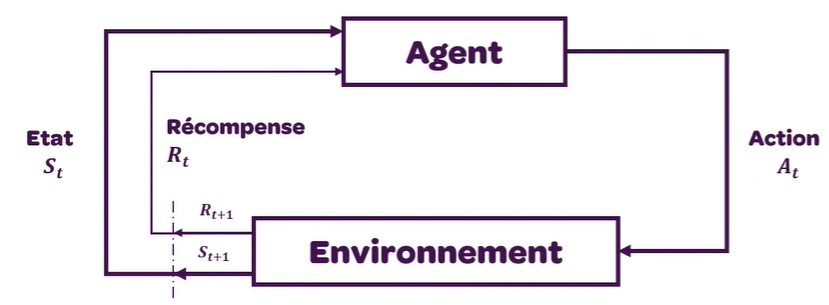

### La formule du Q-Learning

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s,a) \right]$$

Ça parait effrayant, mais décortiquons-la **terme par terme** :

| Terme | Nom | Ce que ça veut dire |
|---|---|---|
| **Q(s,a)** | Valeur actuelle | Ce que l'agent pense de cette action dans cet état |
| **α (alpha)** | Taux d'apprentissage | À quel point on prend en compte la nouvelle info (entre 0 et 1) |
| **r** | Récompense immédiate | Le feedback reçu juste après l'action |
| **γ (gamma)** | Facteur de discount | À quel point on valorise le futur (proche de 1 = vision long terme) |
| **max Q(s', a')** | Meilleure action future | La meilleure valeur possible dans le prochain état |
| **[r + γ·max Q(s',a') - Q(s,a)]** | Erreur de prédiction | La différence entre ce qu'on croyait et ce qu'on vient d'apprendre |




### Le dilemme Exploration vs Exploitation

À chaque étape, l'agent a un choix difficile :

- **Explorer** : essayer une action au hasard, pour découvrir de nouvelles possibilités
- **Exploiter** : faire l'action qu'il pense être la meilleure selon ce qu'il a déjà appris

> Analogie restaurant : tu as un restaurant préféré. Si tu y vas **toujours** (exploitation), tu ne sauras jamais s'il y en a un meilleur dans ta rue. Mais si tu essaies **toujours** de nouveaux endroits (exploration), tu ne profites jamais de ton favori.

**La solution : ε-greedy (epsilon-greedy)**

- On fixe un ε (epsilon) entre 0 et 1
- Avec probabilité **ε** → action **aléatoire** (exploration)
- Avec probabilité **1 - ε** → **meilleure action connue** (exploitation)

**L'astuce importante :** ε diminue au fil du temps.

Au début l'agent ne sait rien → il explore beaucoup.

Avec le temps il apprend → il exploite de plus en plus.

| Phase | ε | Comportement |
|---|---|---|
| Début (épisode 1) | ε = 1.0 | 100% aléatoire |
| Milieu (épisode 250) | ε ≈ 0.3 | 30% exploration / 70% exploitation |
| Fin (épisode 500) | ε ≈ 0.01 | Presque toujours la meilleure action |

### Quand utilise-t-on le Q-Learning ?

Le Q-Learning est fait pour résoudre un type précis de problème :

> **Un agent doit prendre des décisions séquentielles dans un environnement, 
> sans qu'on lui dise à l'avance quoi faire.**

On l'utilise quand :

 ✓ L'environnement a des **états discrets et en nombre limité**

 ✓ Les actions sont **discrètes et en nombre limité**

 ✓ On peut définir une **récompense** claire (gagner/perdre/avancer)
 
 ✓ L'agent apprend **par essai-erreur**, pas depuis un dataset

### Ce que le Q-Learning va résoudre dans notre exemple

**Le problème :** un agent est posé en case (0,0). Il ne sait pas où aller. 
Il ne connaît ni la grille, ni le trésor, ni le piège.

**Ce que le modèle va produire à la fin :**
Pour chaque case de la grille, il va savoir quelle direction prendre.

**Le problème est résolu quand** l'agent trouve le chemin le plus court 
vers le trésor, sans jamais tomber dans le piège.

## 2. Partie Pratique de Q-Learning

### Pourquoi on n'a pas besoin de dataset ?

En Machine Learning classique, tu as besoin d'un dataset **préparé à l'avance** — des milliers d'images labelisées, des données historiques, bref quelqu'un qui a déjà fait le travail de collecter et annoter avant même que tu commences.

En Q-Learning, c'est complètement différent. **L'agent crée ses propres données en vivant.**

Il ne part pas avec un fichier CSV. Il part avec zéro connaissance, il essaie des actions, reçoit des récompenses, et apprend de ses erreurs.

La récompense joue le rôle du label. L'environnement joue le rôle du dataset. Sauf que tout ça se crée **en temps réel**, à chaque action que fait l'agent.

### Le pipeline complet du Q-Learning

En ML classique, le pipeline est linéaire et fixe :
**Données → Preprocessing → Entraînement → Évaluation**

En Q-Learning, le pipeline est **cyclique**. L'agent tourne en boucle, et c'est cette répétition qui produit l'apprentissage.

**Étape 1 — Créer l'environnement**

L'environnement, c'est le "monde" dans lequel l'agent va évoluer. C'est lui qui définit les règles du jeu.

Dans notre cas, c'est une grille 4x4. Chaque case est un état possible. Il y a un trésor à atteindre, et un piège à éviter.

L'environnement doit obligatoirement répondre à deux questions :
- **Que se passe-t-il si l'agent fait cette action ?** → il retourne le nouvel état
- **Quelle récompense l'agent reçoit-il ?** → +10 si trésor, -10 si piège, -1 sinon

> Sans environnement, il n'y a pas d'apprentissage. C'est lui qui fournit le feedback à chaque instant.

---

**Étape 2 — Initialiser la Q-Table**

La Q-Table, c'est la **mémoire de l'agent**. Elle stocke, pour chaque état et chaque action possible, une valeur qui représente "à quel point cette action est bonne dans cette situation".

Au départ, l'agent ne sait rien — toutes les valeurs sont initialisées à 0.


Au fur et à mesure des épisodes, ces valeurs vont se mettre à jour. Certaines vont monter (bonnes actions), d'autres vont descendre (mauvaises actions).

> La Q-Table **est** le modèle en Q-Learning. À la fin de l'entraînement, elle contient toute la stratégie apprise par l'agent.

---

**Étape 3 — Choisir une action (ε-greedy)**

À chaque instant, l'agent doit décider quoi faire. Il applique la stratégie ε-greedy qu'on a vue :
- Si ε est élevé → il explore (action aléatoire)
- Si ε est faible → il exploite (meilleure action dans la Q-Table)

Au début ε = 1.0, il explore tout. À la fin ε ≈ 0.01, il exploite ce qu'il a appris.

---

**Étape 4 — Exécuter l'action et observer**

L'agent exécute l'action choisie. L'environnement lui retourne trois informations :
- **Le nouvel état** — où il se trouve maintenant
- **La récompense reçue** — +10, -10, ou -1
- **Est-ce terminé ?** — a-t-il atteint le trésor ou le piège ?

---

**Étape 5 — Mettre à jour la Q-Table**

C'est ici qu'on applique la formule du Q-Learning :

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s,a) \right]$$

L'agent compare ce qu'il **pensait** que cette action valait, avec ce qu'il **vient de vivre**. Et il ajuste la valeur dans la Q-Table en conséquence.

---

**Étape 6 — Répéter sur plusieurs épisodes**

Un **épisode** = l'agent part de (0,0) et joue jusqu'à atteindre le trésor, tomber dans le piège, ou dépasser 100 steps.

On répète **500 épisodes**. À chaque épisode, ε diminue légèrement. La Q-Table s'affine progressivement jusqu'à converger vers la politique optimale.

---

**Étape 7 — Évaluer l'agent entraîné**

On fait jouer l'agent avec ε = 0 — plus d'exploration, uniquement de l'exploitation. On observe le chemin qu'il choisit et on vérifie qu'il atteint le trésor par le chemin le plus court.


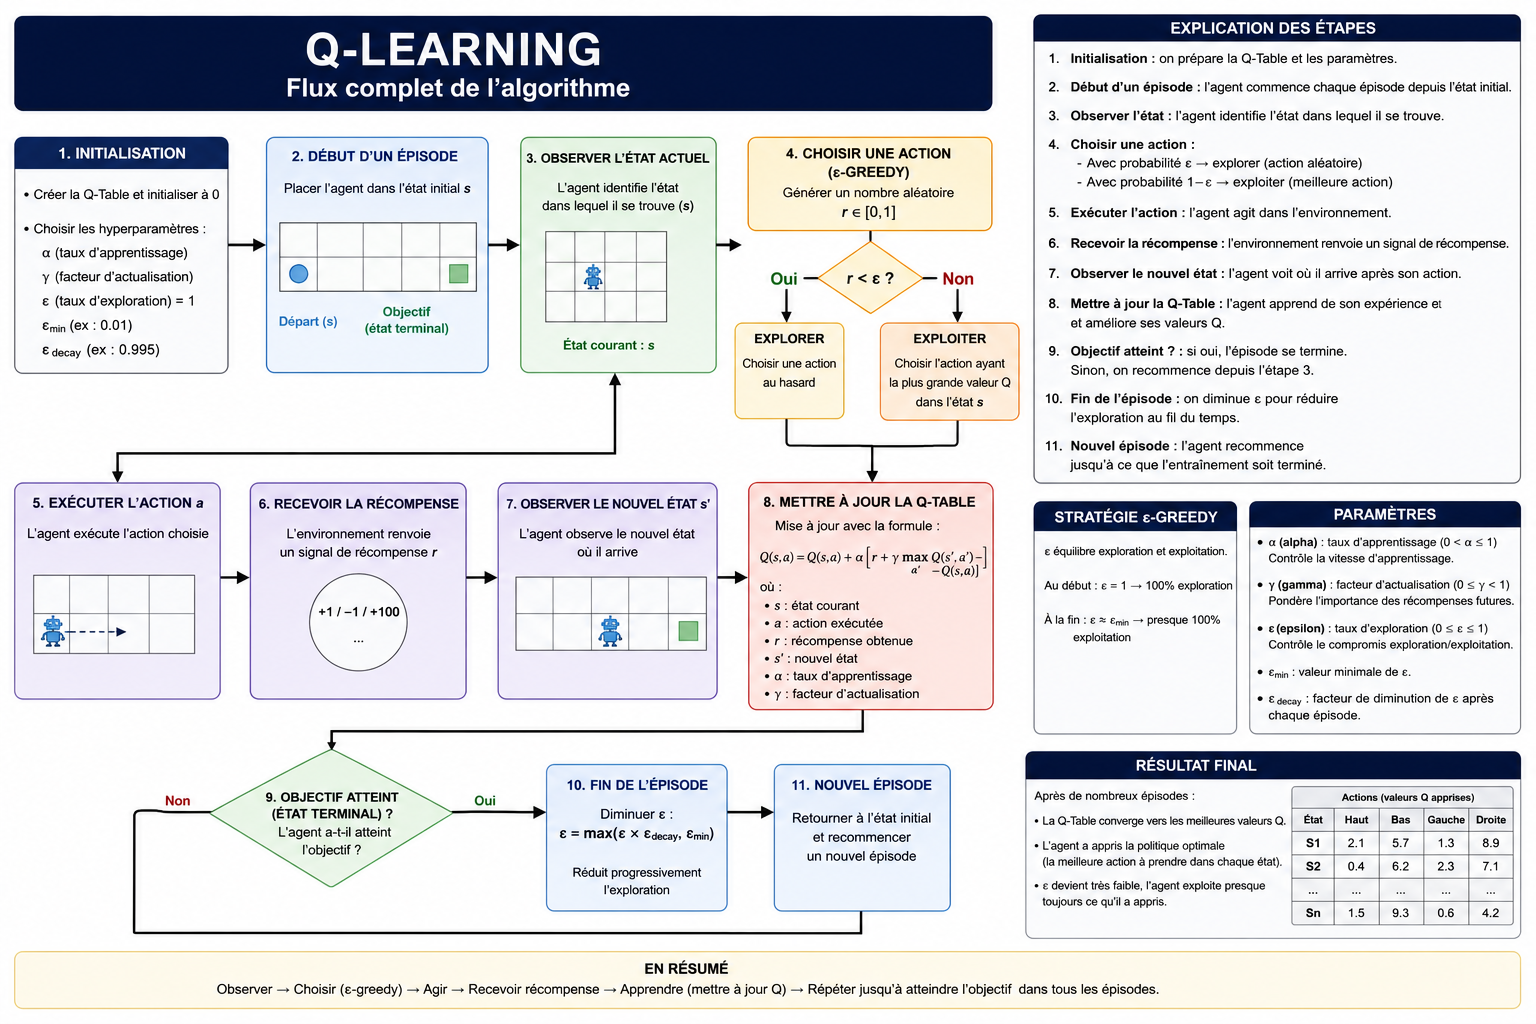